In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from scipy.stats import zscore
import os
import gzip

In [2]:
# Patient dataset
adata_patient = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/KG146_Patient_Organoid.h5ad')

In [5]:
# Prepare the patient 146 dataset
adata_patient = adata_patient[~((adata_patient.obs['Cell State'] == 'NA') | (adata_patient.obs['Cell State'] == 'nan') | (adata_patient.obs['Cell State'] == 'Organoid'))]
adata_patient.obs['Cell State'].value_counts()

Cell State
SCC                 280
ISC-like            252
Injury Repair       230
Enterocyte-like     223
Fetal Progenitor    106
TA-like              80
Goblet-like          71
Early NET            62
Name: count, dtype: int64

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


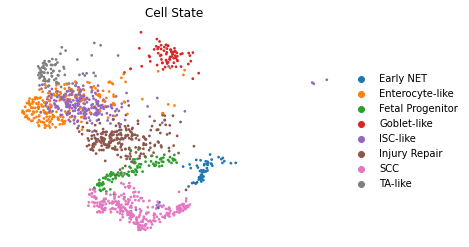

In [6]:
# Plot distribution of cell types
sc.pl.umap(adata_patient, 
           color=['Cell State'], 
           cmap = 'Spectral_r',
           vmin=[0],
           #vmax= [0.2],
           s=30,
           use_raw = False,
           frameon = False)

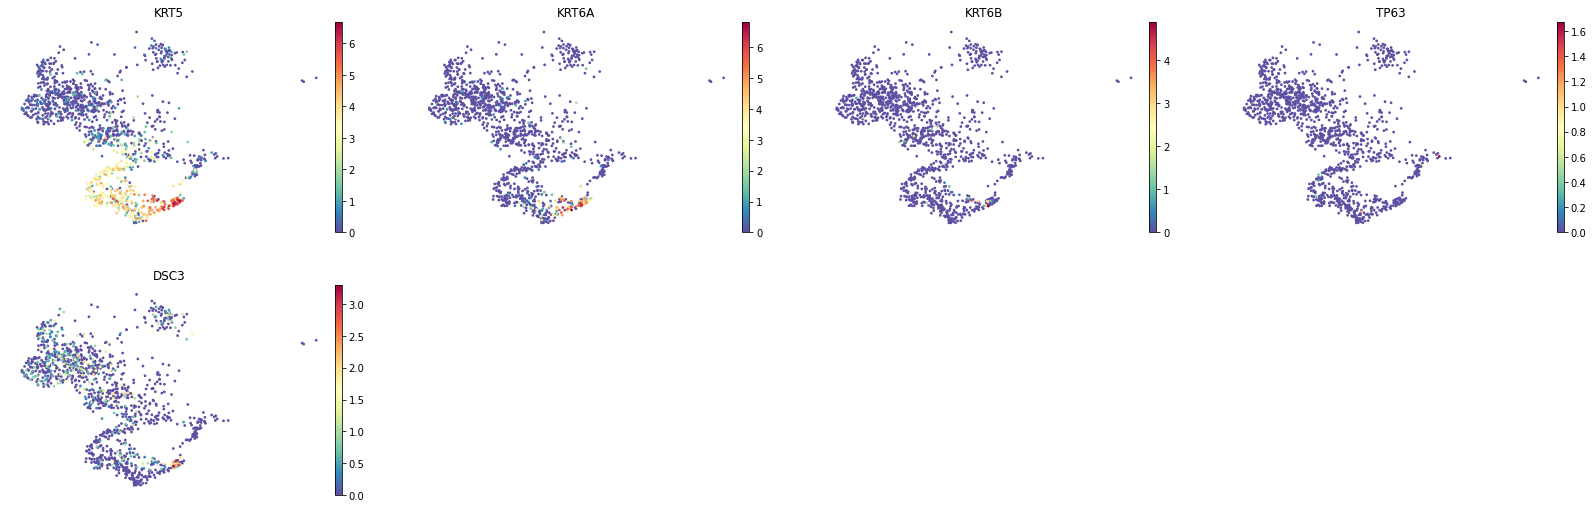

In [7]:
# Plot squamous genes on UMAP
# List of genes to plot
genes_to_plot = ['KRT5','KRT6A','KRT6B','TP63','DSC3','SERPINB3','SERPINB4']
# Filter genes to only those present in adata.var_names or adata.obs.columns
genes_to_plot = [gene for gene in genes_to_plot if gene in adata_patient.var_names or gene in adata_patient.obs.columns]
# Plot UMAP
sc.pl.umap(adata_patient, color=genes_to_plot, cmap='Spectral_r', vmin=[0], s=30, use_raw=False, frameon=False)

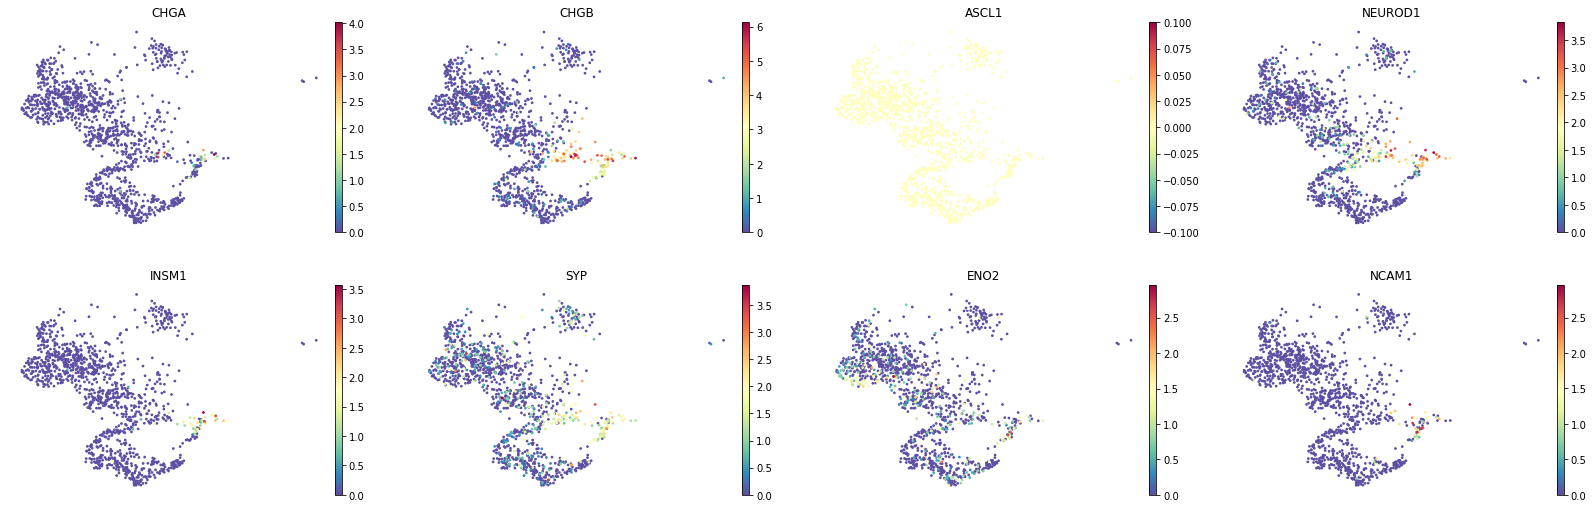

In [8]:
# Plot NE genes on UMAP
# List of genes to plot
genes_to_plot = ['CHGA','CHGB','ASCL1','NEUROD1', 'INSM1', 'SYP', 'ENO2', 'NCAM1']
# Filter genes to only those present in adata.var_names or adata.obs.columns
genes_to_plot = [gene for gene in genes_to_plot if gene in adata_patient.var_names or gene in adata_patient.obs.columns]
# Plot UMAP
sc.pl.umap(adata_patient, color=genes_to_plot, cmap='Spectral_r', vmin=[0], s=30, use_raw=False, frameon=False)

In [3]:
# Look at the number of values for each cell type
adata_patient.obs['Cell State'].value_counts()

Cell State
NA                  9784
nan                  928
SCC                  280
ISC-like             252
Injury Repair        230
Enterocyte-like      223
Fetal Progenitor     106
TA-like               80
Goblet-like           71
Early NET             62
Name: count, dtype: int64

In [6]:
adata_patient

View of AnnData object with n_obs × n_vars = 1304 × 20157
    obs: 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'original_total_counts', 'log10_original_total_counts', 'original_mito_counts', 'log10_original_mito_counts', 'Sample ID', 'emptyDrops_Total', 'emptyDrops_LogProb', 'emptyDrops_PValue', 'emptyDrops_FDR', 'latent_cell_probability', 'PhenoGraph_clusters', 'Smilie Cell Type', 'log10_n_counts', 'frac_counts_gt1_reads', 'n_reads', 'n_reads_per_count', 'n_counts_vs_ED_LogProb', 'n_counts_vs_n_genes_by_counts', 'n_flagged_metrics', 'DC 1', 'DC 2', 'DC 3', 'DC 4', 'DC 5', 'DC 6', 'DC 7', 'Palantir Diff. Potential', 'Palantir Pseudotime', 'Combined Fetal Signature', 'Fi

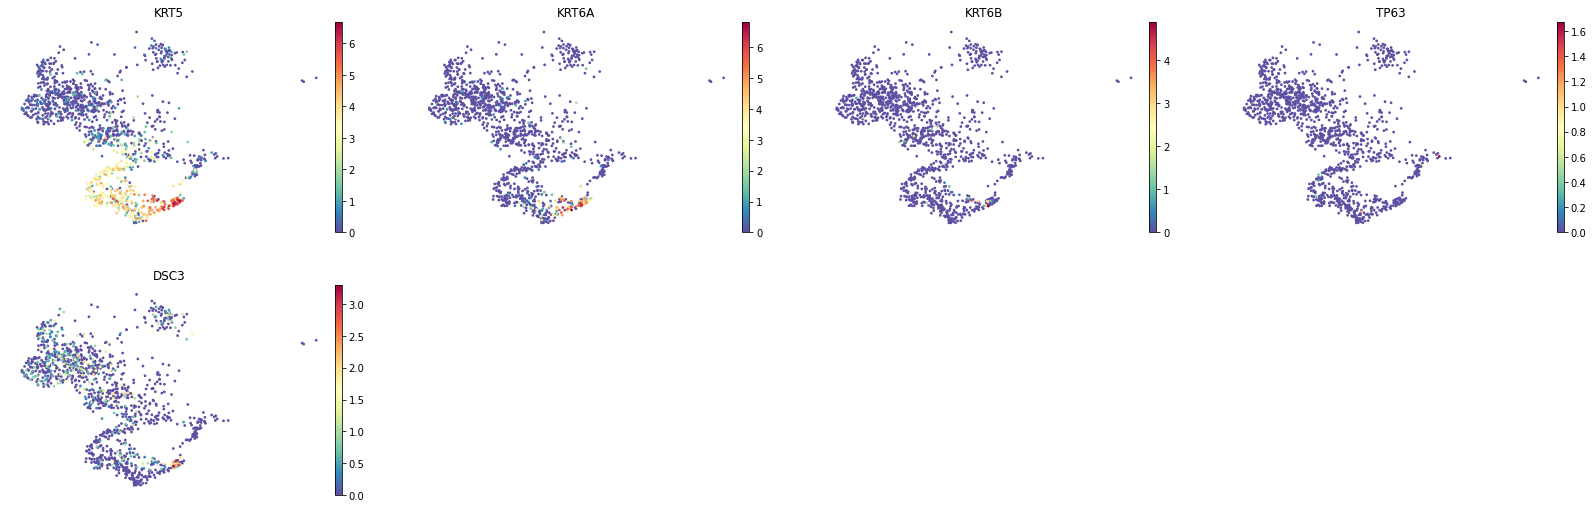

In [27]:
# Plot Squ genes on UMAP
# List of genes to plot
genes_to_plot = ['KRT5','KRT6A','KRT6B','TP63','DSC3','SERPINB3','SERPINB4']
# Filter genes to only those present in adata.var_names or adata.obs.columns
genes_to_plot = [gene for gene in genes_to_plot if gene in adata_patient.var_names or gene in adata_patient.obs.columns]

# Plot UMAP
sc.pl.umap(adata_patient, color=genes_to_plot, cmap='Spectral_r', vmin=[0], s=30, use_raw=False, frameon=False)

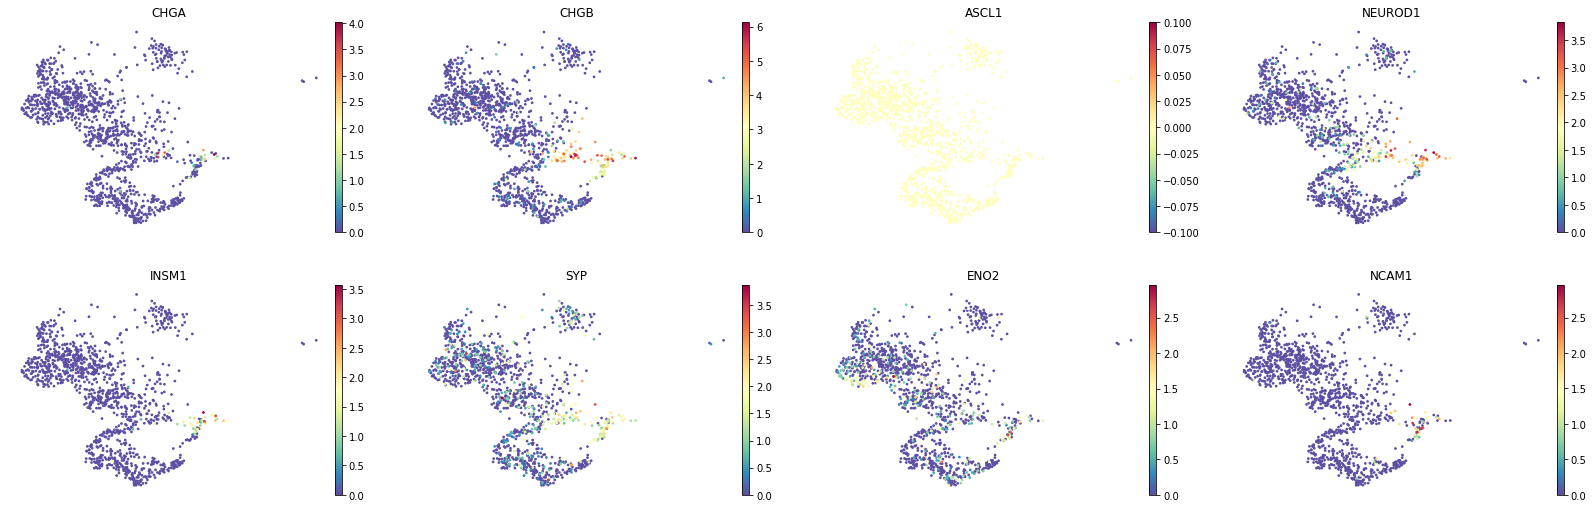

In [31]:
# Plot NE genes on UMAP
# List of genes to plot
genes_to_plot = ['CHGA','CHGB','ASCL1','NEUROD1', 'INSM1', 'SYP', 'ENO2', 'NCAM1']
# Filter genes to only those present in adata.var_names or adata.obs.columns
genes_to_plot = [gene for gene in genes_to_plot if gene in adata_patient.var_names or gene in adata_patient.obs.columns]

# Plot UMAP
sc.pl.umap(adata_patient, color=genes_to_plot, cmap='Spectral_r', s=30, use_raw=False, frameon=False)

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


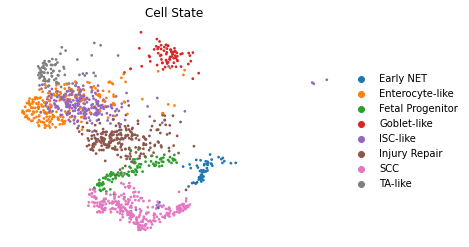

In [30]:
sc.pl.umap(adata_patient, color=['Cell State'], cmap='Spectral_r', vmin=[0], s=30, use_raw=False, frameon=False)

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib

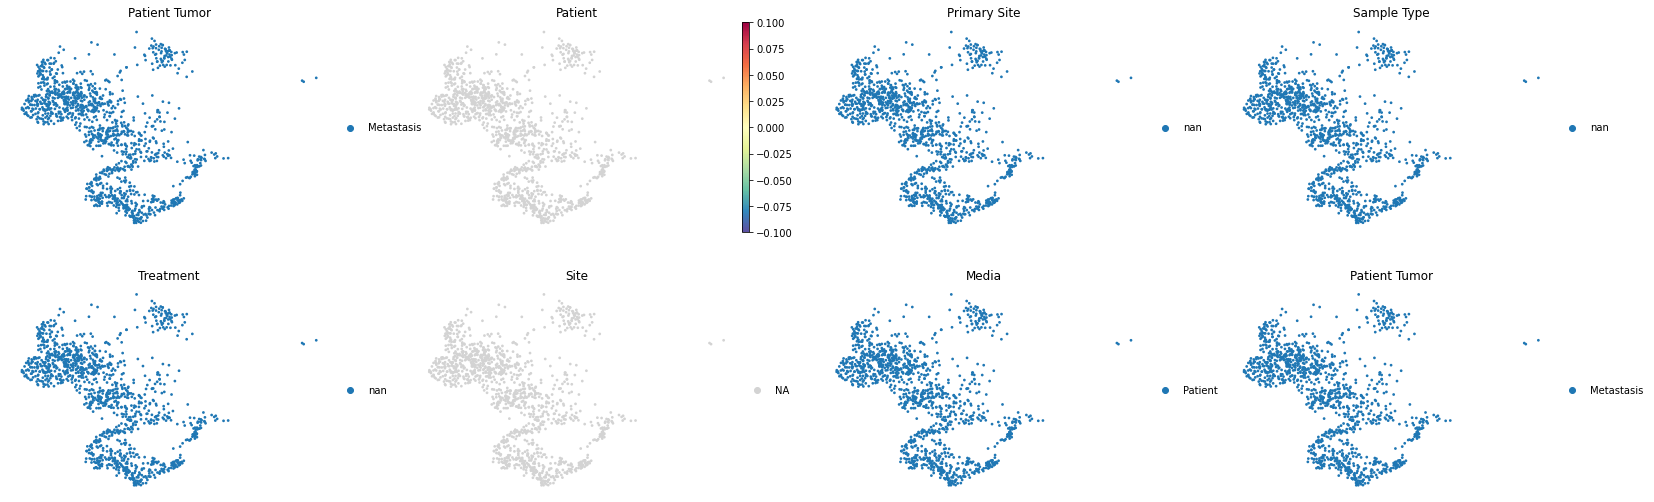

In [37]:
sc.pl.umap(adata_patient, color=['Patient Tumor', 'Patient', 'Primary Site', 
                                 'Sample Type', 'Treatment', 'Site', 
                                'Media', 'Patient Tumor'], 
           cmap='Spectral_r', s=30, use_raw=False, frameon=False)

In [32]:
adata_patient

AnnData object with n_obs × n_vars = 1304 × 20157
    obs: 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'original_total_counts', 'log10_original_total_counts', 'original_mito_counts', 'log10_original_mito_counts', 'Sample ID', 'emptyDrops_Total', 'emptyDrops_LogProb', 'emptyDrops_PValue', 'emptyDrops_FDR', 'latent_cell_probability', 'PhenoGraph_clusters', 'Smilie Cell Type', 'log10_n_counts', 'frac_counts_gt1_reads', 'n_reads', 'n_reads_per_count', 'n_counts_vs_ED_LogProb', 'n_counts_vs_n_genes_by_counts', 'n_flagged_metrics', 'DC 1', 'DC 2', 'DC 3', 'DC 4', 'DC 5', 'DC 6', 'DC 7', 'Palantir Diff. Potential', 'Palantir Pseudotime', 'Combined Fetal Signature', 'First Trim

In [8]:
adata_patient.obs['Patient Tumor']

120703424285939_KG146M    Metastasis
120703436155741_KG146M    Metastasis
120703455025013_KG146M    Metastasis
120718456679846_KG146M    Metastasis
120718468987109_KG146M    Metastasis
                             ...    
241109220584862_KG146M    Metastasis
241176048225691_KG146M    Metastasis
241176061270774_KG146M    Metastasis
241184516782309_KG146M    Metastasis
241184517057252_KG146M    Metastasis
Name: Patient Tumor, Length: 1304, dtype: category
Categories (1, object): ['Metastasis']

In [15]:
# Patient dataset 
adata_patient_2 = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146Li_Base.h5ad')

In [11]:
adata_patient_2.obs['Site']

120703423826332_OKG146Li_Base    NaN
120703436384036_OKG146Li_Base    NaN
120703436605283_OKG146Li_Base    NaN
120718441539813_OKG146Li_Base    NaN
120718441801437_OKG146Li_Base    NaN
                                ... 
165190304708846_KG146P           NaN
161384145836979_KG146P           NaN
200897607945508_KG146P           NaN
125033721486630_KG146P           NaN
200444891487139_KG146P           NaN
Name: Site, Length: 4340, dtype: category
Categories (0, object): []

In [16]:
adata_patient_2.obs['Cell State']
adata_patient_2 = adata_patient_2[~((adata_patient_2.obs['Cell State'] == 'Organoid'))]
adata_patient_2.obs['Cell State'].value_counts()

Cell State
ISC               639
Injury Repair     378
Squamous          279
Proliferative     278
Secretory         239
Absorptive        202
Fetal             107
Neuroendocrine     62
Name: count, dtype: int64

In [23]:
adata_patient_2.obs['Sample Type']

120703424285939_KG146M        nan
120703436155741_KG146M        nan
120703455025013_KG146M        nan
120718456679846_KG146M        nan
120718468987109_KG146M        nan
                           ...   
165190304708846_KG146P    Primary
161384145836979_KG146P    Primary
200897607945508_KG146P    Primary
125033721486630_KG146P    Primary
200444891487139_KG146P    Primary
Name: Sample Type, Length: 2184, dtype: category
Categories (2, object): ['Primary', 'nan']

In [20]:
adata_patient_2

View of AnnData object with n_obs × n_vars = 2184 × 20157
    obs: 'latent_cell_probability', 'filtered_CellBender', 'n_counts', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'original_total_counts', 'log10_original_total_counts', 'original_mito_counts', 'log10_original_mito_counts', 'Sample ID', 'PhenoGraph_clusters', 'PhenoGraph Clusters, k=10', 'PhenoGraph Clusters, k=15', 'PhenoGraph Clusters, k=20', 'PhenoGraph Clusters, k=25', 'PhenoGraph Clusters, k=30', 'PhenoGraph Clusters, k=35', 'PhenoGraph Clusters, k=40', 'PhenoGraph Clusters, k=45', 'PhenoGraph Clusters, k=50', 'PhenoGraph Clusters, k=55', 'PhenoGraph Clusters, k=60', 'PhenoGraph Clusters, Opt', 'Fetal Signature', 'PC 1

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pan

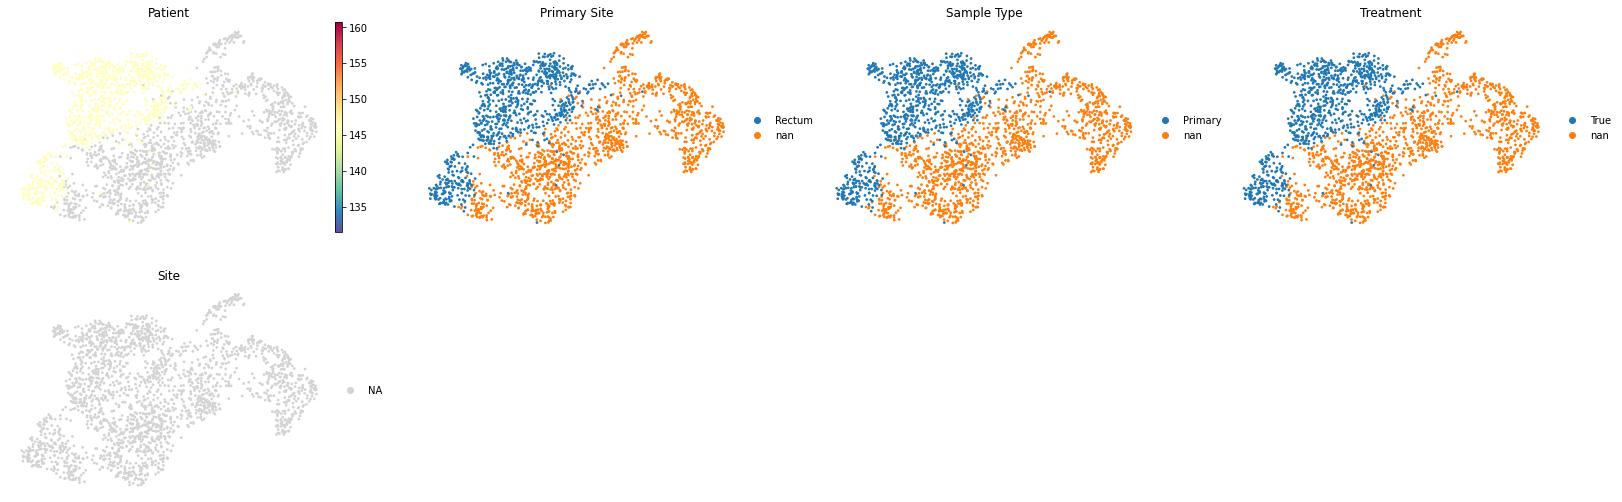

In [38]:
sc.pl.umap(adata_patient_2, color=['Patient', 'Primary Site', 'Sample Type', 'Treatment', 'Site'], 
           cmap='Spectral_r', s=30, use_raw=False, frameon=False)

/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:431: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/forsythb/.local/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


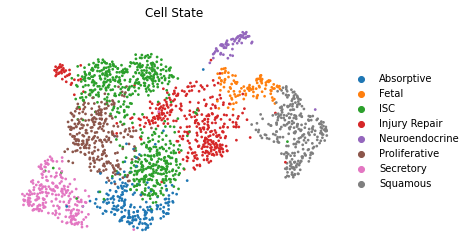

In [17]:
sc.pl.umap(adata_patient_2, color=['Cell State'], 
           cmap='Spectral_r', s=30, use_raw=False, frameon=False)

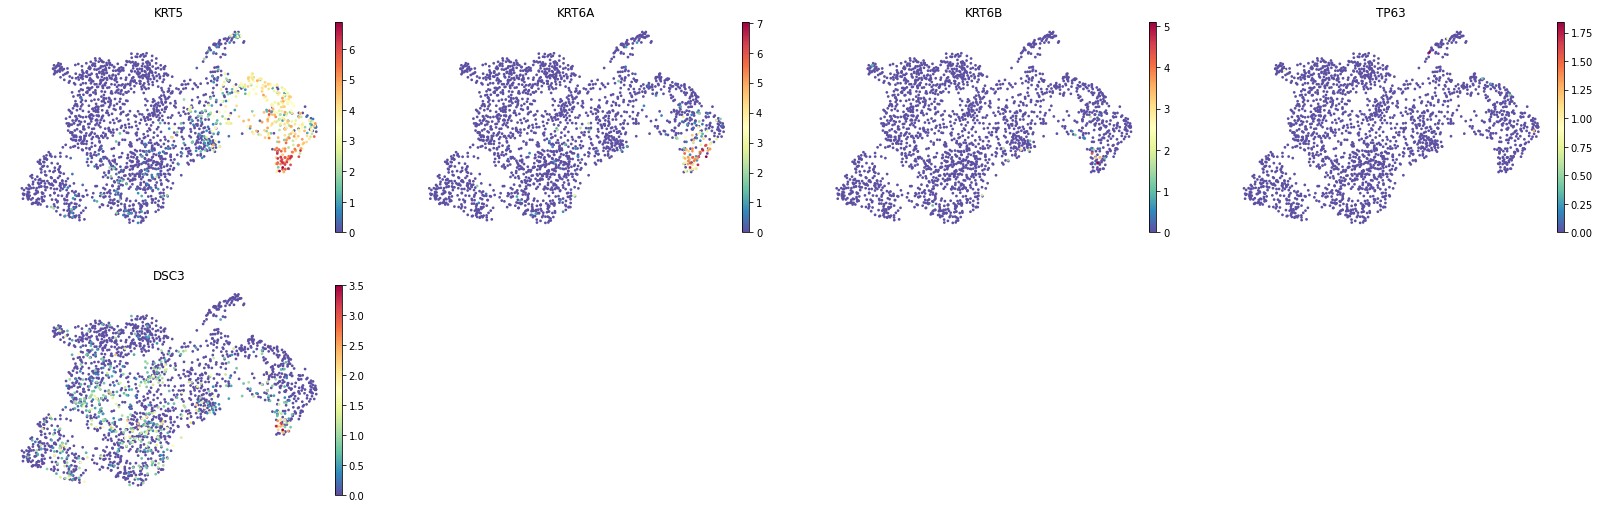

In [18]:
# Plot Squ genes on UMAP
# List of genes to plot
genes_to_plot = ['KRT5','KRT6A','KRT6B','TP63','DSC3','SERPINB3','SERPINB4']
# Filter genes to only those present in adata.var_names or adata.obs.columns
genes_to_plot = [gene for gene in genes_to_plot if gene in adata_patient_2.var_names or gene in adata_patient_2.obs.columns]

# Plot UMAP
sc.pl.umap(adata_patient_2, color=genes_to_plot, cmap='Spectral_r', vmin=[0], s=30, use_raw=False, frameon=False)

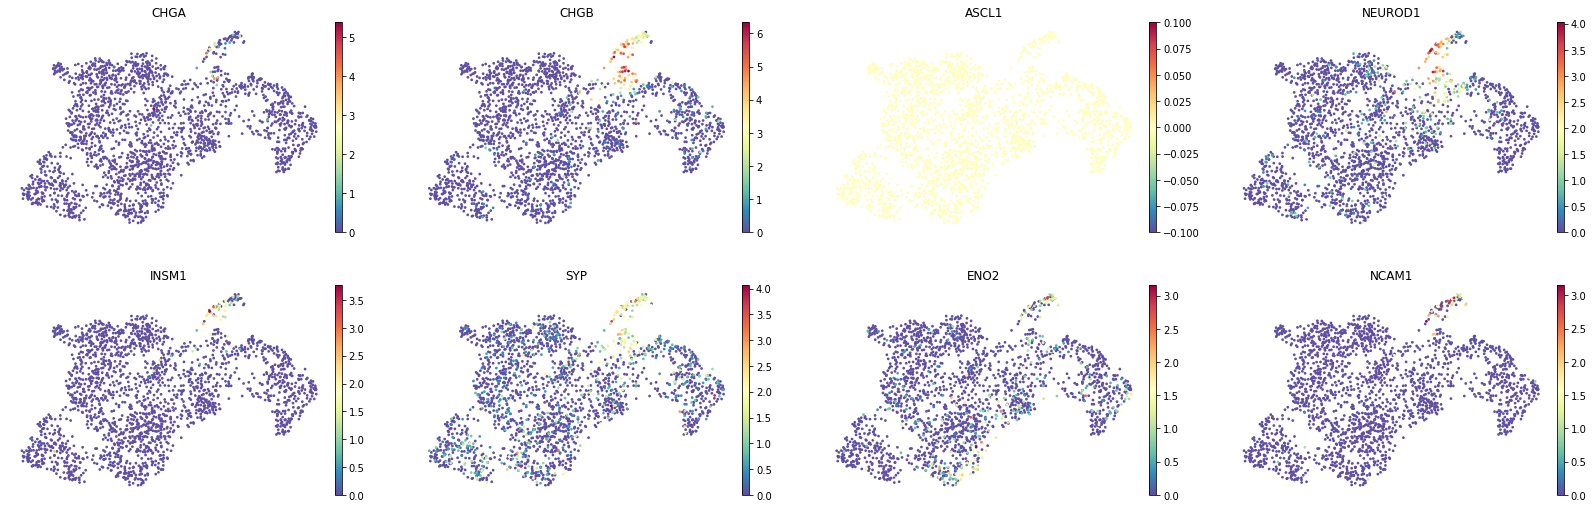

In [19]:
# Plot NE genes on UMAP
# List of genes to plot
genes_to_plot = ['CHGA','CHGB','ASCL1','NEUROD1', 'INSM1', 'SYP', 'ENO2', 'NCAM1']
# Filter genes to only those present in adata.var_names or adata.obs.columns
genes_to_plot = [gene for gene in genes_to_plot if gene in adata_patient_2.var_names or gene in adata_patient_2.obs.columns]

# Plot UMAP
sc.pl.umap(adata_patient_2, color=genes_to_plot, cmap='Spectral_r', s=30, use_raw=False, frameon=False)

In [2]:
adata_liver_base = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146Li_Base.h5ad')

In [5]:
adata_liver_base.obs['Cell State'].value_counts()

Cell State
Organoid          2156
ISC                639
Injury Repair      378
Squamous           279
Proliferative      278
Secretory          239
Absorptive         202
Fetal              107
Neuroendocrine      62
Name: count, dtype: int64

In [20]:
adata_liver_base.obs.index[adata_liver_base.obs['Cell State']=='Organoid']

Index(['120703423826332_OKG146Li_Base', '120703436384036_OKG146Li_Base',
       '120703436605283_OKG146Li_Base', '120718441539813_OKG146Li_Base',
       '120718441801437_OKG146Li_Base', '120718442057005_OKG146Li_Base',
       '120718469285597_OKG146Li_Base', '120718487416155_OKG146Li_Base',
       '120726943057765_OKG146Li_Base', '120728776202139_OKG146Li_Base',
       ...
       '241054849620195_OKG146Li_Base', '241054881044726_OKG146Li_Base',
       '241054881369380_OKG146Li_Base', '241055667799790_OKG146Li_Base',
       '241055686900460_OKG146Li_Base', '241109220879283_OKG146Li_Base',
       '241109239254251_OKG146Li_Base', '241176079621339_OKG146Li_Base',
       '241184504142110_OKG146Li_Base', '241184504663270_OKG146Li_Base'],
      dtype='object', length=2156)

In [6]:
adata_primary_base = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146P_Base.h5ad')

In [7]:
adata_primary_base.obs['Cell State'].value_counts()

Cell State
Organoid          2174
ISC                639
Injury Repair      378
Squamous           279
Proliferative      278
Secretory          239
Absorptive         202
Fetal              107
Neuroendocrine      62
Name: count, dtype: int64

In [21]:
adata_primary_base.obs.loc[adata_primary_base.obs['Cell State']=='Organoid',:]

,latent_cell_probability,filtered_CellBender,n_counts,n_genes,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,Module Injury Repair Score,Module EMT Gene Score,Module EMT Score,Module Neuroendocrine Gene Score,Module Neuroendocrine Score,Cell State Group,Cell State Category,"DC 1, KG146","DC 1, KG146, Mapped","DC 1, KG146, Bin Center"
120703408859571_OKG146P_Base,0.999970,True,20977.0,4614,4614,8.437067,20977.0,9.951229,26.948563,38.423035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.010347,-0.01030
120703423732149_OKG146P_Base,0.999967,True,14399.0,4022,4022,8.299783,14399.0,9.574984,30.564623,40.072227,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.007198,-0.01030
120703423986909_OKG146P_Base,0.999974,True,20686.0,4703,4703,8.456168,20686.0,9.937261,34.119694,43.352992,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008573,-0.00881
120703436417774_OKG146P_Base,0.999963,True,29742.0,4485,4485,8.408717,29742.0,10.300349,42.979625,54.723959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008967,-0.00805
120718456404405_OKG146P_Base,0.999977,True,23692.0,4558,4558,8.424859,23692.0,10.072935,35.940402,49.054533,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009315,-0.00881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241176033584989_OKG146P_Base,0.999971,True,14871.0,3282,3282,8.096513,14871.0,9.607236,41.053056,53.668213,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009186,-0.00881
241184490048293_OKG146P_Base,0.999972,True,18524.0,3898,3898,8.268475,18524.0,9.826877,40.363852,52.807169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008732,-0.00805
241184503905123_OKG146P_Base,0.999961,True,7420.0,2830,2830,7.948385,7420.0,8.912069,28.463612,37.924528,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008106,-0.00805
241184504403814_OKG146P_Base,0.999964,True,25952.0,4605,4605,8.435115,25952.0,10.164042,42.983200,54.361899,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.008289,-0.00805


In [8]:
adata_liver_hisc = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146Li_ENAFI.h5ad')

In [9]:
adata_liver_hisc.obs['Cell State'].value_counts()

Cell State
Organoid          2147
ISC                639
Injury Repair      378
Squamous           279
Proliferative      278
Secretory          239
Absorptive         202
Fetal              107
Neuroendocrine      62
Name: count, dtype: int64

In [10]:
adata_primary_hisc = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/Tumor_Epithelial_KG146_OKG146P_ENAFI.h5ad')

In [11]:
adata_primary_hisc.obs['Cell State'].value_counts()

Cell State
Organoid          2615
ISC                639
Injury Repair      378
Squamous           279
Proliferative      278
Secretory          239
Absorptive         202
Fetal              107
Neuroendocrine      62
Name: count, dtype: int64

In [12]:
adata_146_full = sc.read_h5ad('/data/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/adatas/KG146_Patient_Organoid.h5ad')

In [13]:
adata_146_full.obs['Cell State'].value_counts()

Cell State
NA                  9784
nan                  928
SCC                  280
ISC-like             252
Injury Repair        230
Enterocyte-like      223
Fetal Progenitor     106
TA-like               80
Goblet-like           71
Early NET             62
Name: count, dtype: int64